In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install faiss-cpu

In [3]:
from PIL import Image
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt

In [4]:
# Add src folder to Python path
sys.path.append("../src")

In [5]:
# Define PROJECT_DIR to ensure it's available for path construction
PROJECT_DIR = '/content/drive/MyDrive/product_search_engine'

# Construct the absolute path to the src directory
src_path = os.path.join(PROJECT_DIR, 'src')

# Add the src directory to Python's path if it's not already there
if src_path not in sys.path:
    sys.path.insert(0, src_path) # Use insert(0) to give it higher priority

Import the pipeline

In [6]:
from pipeline import ProductSearchPipeline

In [7]:
# pipeline = ProductSearchPipeline(f"{PROJECT_DIR}/src")
pipeline = ProductSearchPipeline(f"{PROJECT_DIR}")

In [8]:
# Load dataset metadata
df = pd.read_csv(f"{PROJECT_DIR}/data/cleaned_products.csv")

# Get a sample image
sample_image_path = df.iloc[100]["images_path"]
print(f"sample_image_path : {sample_image_path}")

sample_image_path : /content/drive/MyDrive/product_search_engine/data/images/28456.jpg


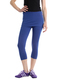

In [9]:
# Load the image
img = Image.open(sample_image_path)
img

### Test Text Search

In [10]:
indices, scores = pipeline.search_text(
    "black leather jacket",
    top_k=5
)

print(indices)
print(scores)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

[36120 28363 27948 11790 11485]
[6.35764   6.1763506 6.1763506 6.1763506 6.1763506]


### Test Image Search

In [15]:
indices, scores = pipeline.search_image(
    img,
    top_k=5
)

print(indices)
print(scores)

[  100  9705 38577 29951 21814]
[11.032488  10.631923  10.630279  10.6185465 10.606467 ]


### Test Multimodal Search

In [16]:
results = pipeline.search_multimodal(
    text = "black jacket",
    image = img,
    top_k = 5,
    alpha = 0.6
)

print(results)

[(np.int64(100), np.float32(4.4129953)), (np.int64(9705), np.float32(4.252769)), (np.int64(38577), np.float32(4.2521114)), (np.int64(29951), np.float32(4.247419)), (np.int64(21814), np.float32(4.242587))]
